# SLIP: Self-supervision Meets Language-Image Pre-training

# https://arxiv.org/abs/2112.12750

## Abstract

This paper investigates whether **self-supervised learning (SSL)** can improve **language-image pre-training** methods such as CLIP. The authors introduce **SLIP (Self-supervision meets Language-Image Pre-training)**, a multi-task learning framework that jointly optimizes a language-image contrastive objective (CLIP) and an image self-supervised objective (SimCLR). Extensive experiments demonstrate that combining these two forms of supervision produces more transferable visual representations than either approach alone, leading to substantial gains in zero-shot transfer, linear classification, and fine-tuning performance across numerous benchmarks.

---

## Problems

The paper addresses several important limitations of existing representation learning approaches:

### 1. Limitations of Self-Supervised Learning

- SSL methods learn strong visual representations.
- However, they cannot naturally perform **zero-shot classification** because they lack an explicit connection between images and language.

### 2. Limitations of CLIP

- CLIP leverages image-caption pairs effectively.
- However, it does not explicitly exploit image-only invariances learned through self-supervision.

### 3. Objective Compatibility

It is unclear whether language supervision and self-supervision are complementary or conflicting objectives because they may encourage different representations of the same image.

### 4. Learning from Large Uncurated Data

Existing self-supervised methods often struggle to scale effectively on noisy web-scale datasets such as YFCC100M.

---

## Proposed Solution

The authors propose **SLIP**, a unified multi-task framework that combines:

1. **CLIP Language-Image Contrastive Learning**
2. **SimCLR Self-Supervised Contrastive Learning**

Both objectives share a common image encoder and are optimized jointly during training.

The overall training objective is:

$$
L_{\text{SLIP}} = L_{\text{CLIP}} + \lambda L_{\text{SSL}}
$$

where:

- $L_{\text{CLIP}}$ is the language-image contrastive loss.
- $L_{\text{SSL}}$ is the self-supervised contrastive loss.
- $\lambda$ controls the balance between the two objectives.

This enables the model to simultaneously learn:

- Semantic alignment between images and text.
- Visual invariances from multiple image views.

---

## Purpose

The primary objective of the paper is to answer the following research question:

> Can self-supervised learning improve language-image pre-training?

More specifically, the authors aim to:

- Improve CLIP's representation quality.
- Enhance zero-shot classification performance.
- Improve downstream task accuracy.
- Investigate whether language supervision and self-supervision complement each other.
- Evaluate scalability across datasets, model sizes, and training schedules.

---

## Methodology

### Framework Architecture

SLIP consists of:

- A shared Vision Transformer (ViT) image encoder.
- A CLIP text encoder.
- A CLIP projection head.
- A SimCLR projection head.

For each training sample:

- One image crop is used for the CLIP objective.
- Two augmented views are used for the self-supervised objective.

Both losses are computed simultaneously and summed.

### CLIP Objective

CLIP learns aligned image and text embeddings through contrastive learning.

Given image embeddings $z_i$ and text embeddings $z_t$:

$$
\text{logit} = e^s z_i z_t^T
$$

where:

- $s$ is a learnable temperature parameter.

Cross-entropy loss is applied in both image-to-text and text-to-image directions.

### Self-Supervised Objective

The SSL branch follows SimCLR.

Two augmented views of the same image are treated as positive pairs, while all other images in the batch serve as negatives.

The objective encourages:

$$
z_1 \approx z_2
$$

for different augmentations of the same image.

### Datasets

The experiments use:

- YFCC15M
- CC3M
- CC12M

### Evaluation Protocols

The learned representations are evaluated using:

#### Zero-Shot Transfer

No model parameters are updated.

#### Linear Classification

The encoder is frozen and only a linear classifier is trained.

#### End-to-End Fine-Tuning

The entire model is fine-tuned on downstream tasks.

---

## Results

### ImageNet Performance

#### ViT-B/16 Results

| Method | Zero-Shot | Linear | Fine-Tuned |
|----------|----------|----------|----------|
| CLIP | 37.6% | 66.5% | 80.5% |
| SimCLR | — | 64.0% | 82.5% |
| SLIP | 42.8% | 72.1% | 82.6% |

SLIP achieves:

- **+5.2%** improvement in zero-shot accuracy over CLIP.
- **+5.6%** improvement in linear classification over CLIP.
- Slight improvement in fine-tuning performance.

### Scaling Results

Performance consistently improves with:

- Larger Vision Transformers.
- Longer training schedules.

For ViT-L/16 trained for 100 epochs:

| Metric | Accuracy |
|----------|----------|
| Zero-Shot | 47.9% |
| Linear | 75.1% |
| Fine-Tuned | 84.8% |

### Generalization Across Datasets

The authors evaluate SLIP on more than 25 downstream benchmarks.

Key findings:

- SLIP outperforms CLIP on most datasets.
- Improvements are especially strong on datasets whose concepts are well represented in web-scale image collections.
- Gains remain consistent across multiple model sizes.

### Alternative SSL Objectives

The authors replace SimCLR with other SSL methods.

| Method | Zero-Shot |
|----------|----------|
| CLIP | 37.6% |
| SLIP-BEiT | 39.1% |
| SLIP-BYOL | 41.3% |
| SLIP-MoCo v3 | 41.8% |
| SLIP-SimCLR | 42.8% |

Although all SSL variants improve CLIP, SimCLR performs best within the SLIP framework.

---

## Conclusions

The paper demonstrates that **language supervision and self-supervision are highly complementary**.

### Main Findings

#### 1. Joint Training Outperforms Individual Training

SLIP consistently achieves better results than either:

- CLIP alone.
- Self-supervised learning alone.

#### 2. Self-Supervision Significantly Enhances CLIP

The largest gains occur in:

- Zero-shot transfer.
- Linear probing.

#### 3. Benefits Scale with Model Size

Performance improvements persist as:

- Models become larger.
- Training duration increases.

#### 4. Joint Optimization Is Better Than Sequential Training

Pre-training with SSL and subsequently training CLIP performs worse than optimizing both objectives simultaneously.

#### 5. Improvements Are Not Due to Data Augmentation Alone

Additional augmentations improve CLIP only slightly and cannot explain SLIP's large gains.

#### 6. Best of Both Worlds

SLIP combines:

- The semantic alignment and zero-shot capabilities of CLIP.
- The robust visual representation learning of self-supervised methods.

---

## Key Takeaway

SLIP provides strong evidence that future vision foundation models should not treat language supervision and self-supervised learning as competing paradigms.

Instead, jointly optimizing both objectives produces richer, more transferable, and more scalable visual representations than either approach can achieve independently.

# Mathematical and Statistical Content in SLIP

## Overview

The SLIP paper is primarily an empirical machine learning paper rather than a mathematically theoretical one. Its mathematical content focuses on:

1. Contrastive learning objectives.
2. Representation learning.
3. Similarity-based optimization.
4. Cross-entropy loss minimization.
5. Statistical evaluation through classification accuracy.

The core mathematical contribution is the combination of two learning objectives:

- CLIP contrastive language-image learning.
- SimCLR self-supervised contrastive learning.

---

# 1. Multi-Task Learning Objective

## Equation

The central idea of SLIP is to optimize two losses simultaneously:

$$
L_{\text{SLIP}}
=
L_{\text{CLIP}}
+
cL_{\text{SSL}}
$$

where:

- $L_{\text{CLIP}}$ = language-image contrastive loss.
- $L_{\text{SSL}}$ = self-supervised learning loss.
- $c$ = weighting coefficient.

## Meaning

This equation tells the model to learn from:

- Image-text relationships.
- Image-image relationships.

at the same time.

## Role in the Paper

This is the fundamental mathematical idea behind SLIP.

The paper investigates whether learning both objectives jointly produces better visual representations than learning either objective alone.

---

# 2. Embedding Spaces

## Concept

Images and text are converted into vectors:

$$
z_i
$$

for images and

$$
z_t
$$

for text.

These vectors are mapped into a common embedding space.

## Meaning

Similar images and captions should have nearby vectors.

For example:

- image of a dog
- caption "a dog"

should produce similar embeddings.

## Role in the Paper

This shared representation space enables:

- zero-shot classification,
- image retrieval,
- text-guided recognition.

---

# 3. Vector Normalization

Before computing similarities, embeddings are normalized:

$$
z
=
\frac{z}{\|z\|}
$$

## Meaning

Normalization forces every vector to have unit length.

This makes similarity depend only on direction rather than magnitude.

## Role in the Paper

Used in both:

- CLIP loss
- SimCLR loss

to stabilize training.

---

# 4. Dot Product Similarity

## Equation

Similarity between two embeddings is computed using:

$$
s
=
z_i^T z_t
$$

## Meaning

The dot product measures alignment between vectors.

Higher values indicate stronger semantic similarity.

## Role in the Paper

Used to determine:

- which image matches which caption,
- which image augmentations belong together.

---

# 5. CLIP Contrastive Objective

## Similarity Matrix

For a batch of size $N$:

$$
S
=
z_i z_t^T
$$

where:

- rows correspond to images,
- columns correspond to captions.

## Meaning

Each cell contains the similarity between an image and a caption.

The diagonal entries correspond to correct image-caption pairs.

---

## Temperature Scaling

The similarity matrix is scaled:

$$
\text{logit}
=
e^s
z_i z_t^T
$$

where:

$$
s
$$

is a learnable parameter.

## Meaning

Controls the sharpness of the probability distribution.

Higher temperatures produce softer predictions.

Lower temperatures produce sharper predictions.

## Role in the Paper

Improves optimization and training stability.

---

## Cross-Entropy Loss

For image-to-text matching:

$$
L_i
=
\text{CrossEntropy}
(\text{logit}, label)
$$

For text-to-image matching:

$$
L_t
=
\text{CrossEntropy}
(\text{logit}^T, label)
$$

Final CLIP loss:

$$
L_{\text{CLIP}}
=
\frac{L_i + L_t}{2}
$$

## Meaning

The model learns to:

- match correct image-caption pairs,
- reject incorrect pairs.

## Role in the Paper

This is the language supervision component.

---

# 6. SimCLR Self-Supervised Objective

## Positive Pairs

Two augmentations:

$$
x_1, x_2
$$

are generated from the same image.

The model should learn:

$$
z_1 \approx z_2
$$

## Meaning

Different views of the same image should produce similar representations.

---

## Contrastive Learning

The model maximizes similarity between:

$$
(z_1,z_2)
$$

and minimizes similarity with all other images.

## Role in the Paper

This teaches the model visual invariances such as:

- rotation,
- color changes,
- cropping,
- viewpoint changes.

---

# 7. InfoNCE Loss

The contrastive losses used by both CLIP and SimCLR belong to the InfoNCE family.

Simplified form:

$$
L
=
-\log
\frac{
\exp(\text{sim}(x,x^+)/\tau)
}
{
\sum_j
\exp(\text{sim}(x,x_j)/\tau)
}
$$

where:

- $x^+$ = positive sample.
- $x_j$ = positive and negative samples.
- $\tau$ = temperature parameter.

## Meaning

The objective rewards:

- high similarity for positives,
- low similarity for negatives.

## Role in the Paper

The mathematical foundation behind contrastive learning.

---

# 8. Temperature Parameter

## Equation

$$
\tau
$$

appears in SimCLR's softmax computation.

## Meaning

Controls how strongly negatives are separated.

Small $\tau$:

- harder discrimination.

Large $\tau$:

- softer discrimination.

## Role in the Paper

Critical hyperparameter for contrastive learning.

---

# 9. Matrix Operations

The paper relies heavily on matrix multiplication:

$$
Z_i Z_t^T
$$

and

$$
Z_1 Z_2^T
$$

## Meaning

Computes all pairwise similarities simultaneously.

## Role in the Paper

Allows efficient contrastive learning over thousands of samples in a batch.

---

# 10. Statistical Evaluation Metrics

The paper evaluates models using classification accuracy.

---

## Top-1 Accuracy

$$
\text{Accuracy}
=
\frac{
\text{Correct Predictions}
}
{
\text{Total Predictions}
}
\times 100
$$

## Meaning

Percentage of correctly classified samples.

## Role in the Paper

Primary evaluation metric.

---

# 11. Zero-Shot Transfer Evaluation

## Statistical Idea

No parameters are updated.

Classification is performed by:

1. Encoding class names as text.
2. Computing image-text similarity.
3. Selecting the most similar class.

Formally:

$$
\hat{y}
=
\arg\max_j
\text{sim}(z_i,z_j)
$$

## Role in the Paper

Measures how well learned representations generalize without retraining.

---

# 12. Linear Probing

## Procedure

The encoder remains frozen.

Only a linear classifier is trained:

$$
y
=
Wx+b
$$

## Meaning

Tests the quality of learned representations.

If a simple linear model performs well, the representation is considered informative.

## Role in the Paper

Major evaluation protocol throughout the paper.

---

# 13. End-to-End Fine-Tuning

## Procedure

All parameters are updated:

$$
\theta
\leftarrow
\theta - \eta \nabla_\theta L
$$

where:

- $\eta$ = learning rate.
- $\nabla_\theta L$ = gradient.

## Meaning

Measures how useful pre-training is for downstream adaptation.

## Role in the Paper

Third major evaluation protocol.

---

# 14. Scaling Analysis

The paper statistically studies:

- model size scaling,
- training duration scaling.

Examples:

| Model | Parameters |
|---------|---------:|
| ViT-S | 22M |
| ViT-B | 86M |
| ViT-L | 307M |

## Finding

Performance generally increases as:

- parameter count increases,
- training epochs increase.

This is an empirical scaling-law observation rather than a theoretical result.

---

# 15. Experimental Statistics

The paper reports improvements such as:

| Comparison | Improvement |
|------------|------------|
| SLIP vs CLIP (Zero-shot) | +5.2% |
| SLIP vs CLIP (Linear) | +5.6% |
| SLIP vs SSL (Linear) | +8.1% |

## Meaning

These percentage-point gains quantify the effectiveness of combining:

- language supervision,
- self-supervision.

---

# Key Mathematical Takeaway

Mathematically, SLIP is built upon a simple but powerful principle:

$$
\text{Language Supervision}
+
\text{Self-Supervision}
=
\text{Better Representation Learning}
$$

The paper's mathematical foundation comes from **contrastive learning**, where representations are optimized by maximizing similarity between related samples and minimizing similarity between unrelated samples. SLIP extends this idea by applying contrastive learning simultaneously across both image-text pairs (CLIP) and image-image pairs (SimCLR), producing richer and more transferable visual representations.

| Research Problem / Gap | Limitation of Prior Work | Proposed Solution in SLIP |
|----------|----------|----------|
| Self-supervised learning (SSL) produces strong visual representations but lacks zero-shot classification capability. | SSL methods learn image representations without language alignment, making it impossible to directly classify images using natural language prompts. | Combine SSL with CLIP-style language-image supervision so that learned representations retain strong visual features while supporting zero-shot transfer. |
| CLIP relies exclusively on image-text supervision and may not fully exploit image-only visual structure. | CLIP learns semantic alignment between images and text but does not explicitly enforce visual invariances learned through self-supervised objectives. | Introduce a joint training framework that simultaneously optimizes language-image contrastive learning and image self-supervised learning. |
| Uncertainty regarding whether language supervision and self-supervision are complementary or conflicting objectives. | The two objectives encourage different forms of representation learning, potentially causing optimization interference and degraded performance. | Design a multi-task learning framework (SLIP) with a shared image encoder trained jointly on both objectives, and empirically evaluate their interaction. |
| Limited understanding of how self-supervised learning behaves when combined with web-scale language supervision. | Prior SSL research primarily focused on image-only datasets such as ImageNet and did not investigate synergy with large-scale image-text learning. | Systematically study the integration of SSL and CLIP across multiple datasets, model scales, and evaluation protocols. |
| Existing SSL methods show reduced effectiveness when trained on large uncurated web datasets. | Self-supervised models often experience significant performance degradation when moving from curated datasets (e.g., ImageNet) to noisy datasets such as YFCC15M. | Use language supervision as an additional learning signal while retaining self-supervised objectives, improving representation quality on uncurated web-scale data. |
| CLIP representations exhibit relatively weak downstream fine-tuning performance compared to strong SSL methods. | Although CLIP performs well in zero-shot settings, its learned visual representations are less effective for some downstream adaptation tasks. | Enhance CLIP representations with self-supervised learning, resulting in improved linear probing and fine-tuning performance. |
| Sequential training (SSL pre-training followed by CLIP training) may not fully exploit complementary information. | Fine-tuning a CLIP model initialized from SSL weights leads to weaker performance than expected because the benefits of both objectives are not jointly optimized. | Train both objectives simultaneously within a unified multi-task framework, allowing the encoder to learn complementary signals throughout training. |
| Improvements in CLIP performance could potentially be attributed only to stronger data augmentation. | Prior improvements might be explained by augmentation strategies rather than genuine representation learning benefits. | Conduct controlled experiments showing that augmentation alone provides only minor gains, while joint SSL and language supervision produces substantially larger improvements. |
| Lack of a unified framework that combines the strengths of language supervision and self-supervision. | Existing methods typically choose either language-image pre-training or self-supervised learning, missing potential synergies between them. | Introduce SLIP (Self-supervision meets Language-Image Pre-training), a unified framework that leverages both paradigms to achieve superior zero-shot transfer, linear classification, and fine-tuning performance. |

In [1]:
# ============================================================
# SLIP-Style Educational Implementation on Fashion-MNIST
# ============================================================
# This notebook cell demonstrates the core idea behind:
#
# "SLIP: Self-supervision Meets Language-Image Pre-training"
#
# Original Paper:
#   Jointly train with:
#       1. CLIP Loss (image-text supervision)
#       2. SimCLR Loss (self-supervision)
#
# Fashion-MNIST does not provide captions.
#
# Therefore we create an educational version:
#
#       SLIP Loss
#            =
#       Classification Loss
#            +
#       SimCLR Contrastive Loss
#
# This demonstrates the central insight of SLIP:
#
#       Supervision + Self-Supervision
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:

# ============================================================
# Device
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# ============================================================
# Class Names
# ============================================================

classes = [
    "T-Shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]


In [4]:
# ============================================================
# SimCLR-style Augmentation
# ============================================================

augmentation = transforms.Compose([
    transforms.RandomResizedCrop(28, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])


In [5]:
# ============================================================
# Normal Transform
# ============================================================

basic_transform = transforms.ToTensor()

In [6]:
# ============================================================
# Dataset Wrapper
# Creates TWO augmented views of the same image
# ============================================================

class ContrastiveFashionMNIST(torchvision.datasets.FashionMNIST):

    def __getitem__(self, index):

        image, label = self.data[index], int(self.targets[index])

        image = transforms.ToPILImage()(image)

        view1 = augmentation(image)
        view2 = augmentation(image)

        supervised_view = basic_transform(image)

        return supervised_view, view1, view2, label


In [7]:

# ============================================================
# Load Dataset
# ============================================================

train_dataset = ContrastiveFashionMNIST(
    root="./data",
    train=True,
    download=True
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=basic_transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.7MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.3MB/s]


In [8]:
# ============================================================
# Shared Encoder
# ============================================================

class Encoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

    def forward(self,x):

        x = self.features(x)
        x = torch.flatten(x,1)

        return x


In [9]:
# ============================================================
# SLIP-style Network
# ============================================================

class SLIPFashion(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = Encoder()

        # supervised head
        self.classifier = nn.Linear(128,10)

        # projection head
        self.projector = nn.Sequential(
            nn.Linear(128,256),
            nn.ReLU(),
            nn.Linear(256,128)
        )

    def forward(self,x):

        features = self.encoder(x)

        logits = self.classifier(features)

        projections = self.projector(features)

        return logits, projections, features

In [10]:
model = SLIPFashion().to(device)

In [11]:
# ============================================================
# SimCLR NT-Xent Loss
# ============================================================

def simclr_loss(z1,z2,temperature=0.5):

    batch_size = z1.size(0)

    z1 = F.normalize(z1,dim=1)
    z2 = F.normalize(z2,dim=1)

    representations = torch.cat([z1,z2],dim=0)

    similarity_matrix = (
        representations @ representations.T
    )

    mask = torch.eye(
        2*batch_size,
        device=device
    ).bool()

    similarity_matrix = similarity_matrix.masked_fill(mask,-1e9)

    positives = torch.cat([
        torch.diag(similarity_matrix,batch_size),
        torch.diag(similarity_matrix,-batch_size)
    ])

    numerator = torch.exp(
        positives/temperature
    )

    denominator = torch.sum(
        torch.exp(similarity_matrix/temperature),
        dim=1
    )

    loss = -torch.log(
        numerator / denominator
    ).mean()

    return loss


In [12]:
# ============================================================
# Losses
# ============================================================

classification_loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [13]:
# ============================================================
# Training
# ============================================================

epochs = 10

loss_history = []
acc_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for supervised_img, view1, view2, labels in train_loader:

        supervised_img = supervised_img.to(device)
        view1 = view1.to(device)
        view2 = view2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # -------------------------
        # Classification branch
        # -------------------------

        logits, _, _ = model(supervised_img)

        cls_loss = classification_loss(
            logits,
            labels
        )

        # -------------------------
        # SimCLR branch
        # -------------------------

        _, z1, _ = model(view1)
        _, z2, _ = model(view2)

        ssl_loss = simclr_loss(z1,z2)

        # -------------------------
        # SLIP Loss
        # -------------------------

        total_loss = cls_loss + ssl_loss

        total_loss.backward()

        optimizer.step()

        running_loss += total_loss.item()

        predictions = logits.argmax(1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    epoch_loss = running_loss/len(train_loader)
    epoch_acc = 100*correct/total

    loss_history.append(epoch_loss)
    acc_history.append(epoch_acc)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Loss {epoch_loss:.4f} | "
        f"Accuracy {epoch_acc:.2f}%"
    )


Epoch 01/10 | Loss 6.2536 | Accuracy 50.45%
Epoch 02/10 | Loss 5.3585 | Accuracy 72.43%
Epoch 03/10 | Loss 5.2178 | Accuracy 75.18%
Epoch 04/10 | Loss 5.1352 | Accuracy 77.29%
Epoch 05/10 | Loss 5.0716 | Accuracy 78.76%
Epoch 06/10 | Loss 5.0192 | Accuracy 80.61%
Epoch 07/10 | Loss 4.9801 | Accuracy 81.66%
Epoch 08/10 | Loss 4.9494 | Accuracy 82.64%
Epoch 09/10 | Loss 4.9205 | Accuracy 83.50%
Epoch 10/10 | Loss 4.8963 | Accuracy 84.13%


In [15]:
# ============================================================
# Evaluation
# ============================================================

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits, _, _ = model(images)

        preds = logits.argmax(1)

        total += labels.size(0)

        correct += (
            preds == labels
        ).sum().item()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

test_accuracy = 100*correct/total

print("\nTest Accuracy:", round(test_accuracy,2), "%")


Test Accuracy: 84.05 %


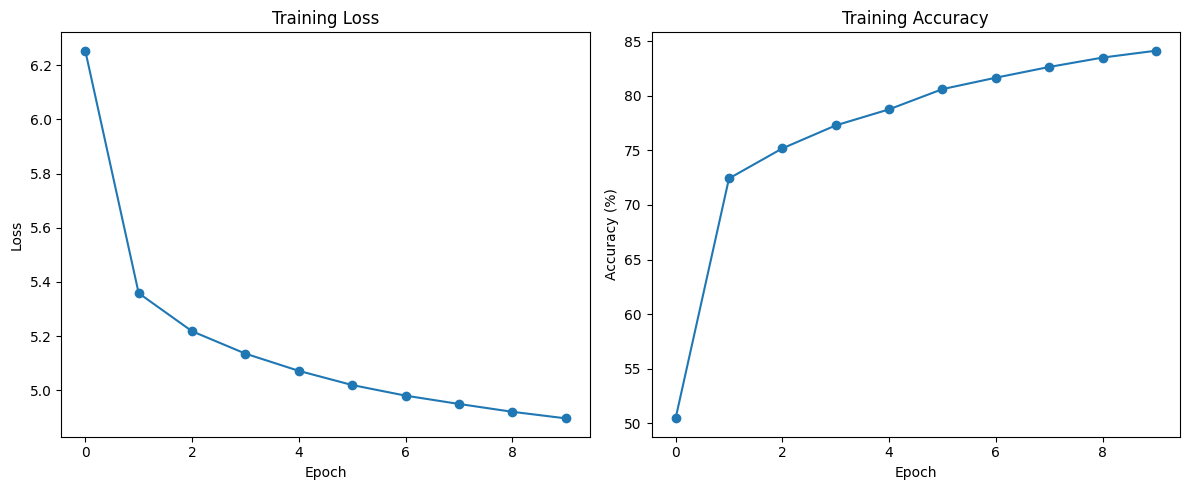

In [16]:
# ============================================================
# Plot Training Curves
# ============================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_history, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(acc_history, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


<Figure size 800x800 with 0 Axes>

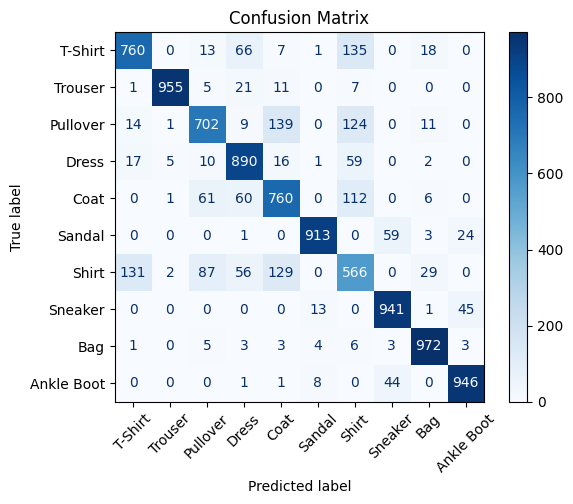

In [17]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

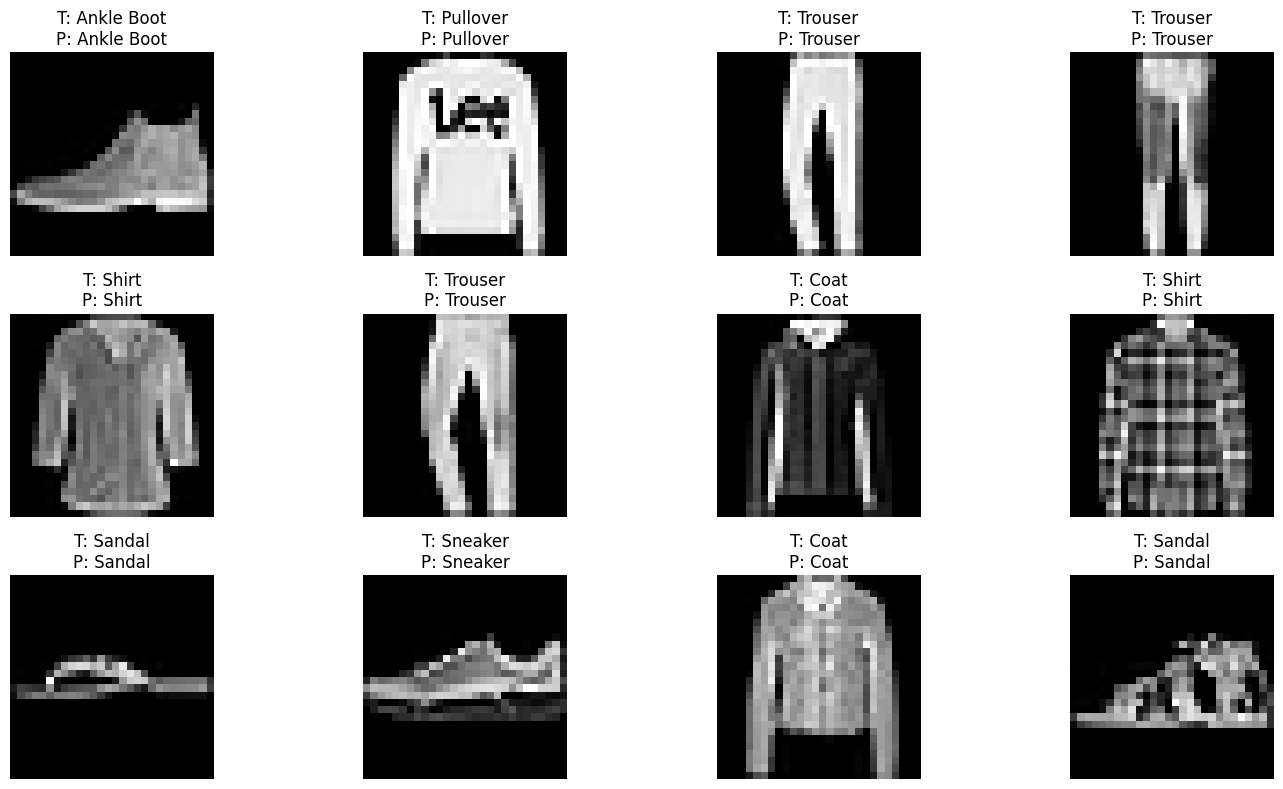

In [18]:

# ============================================================
# Sample Predictions
# ============================================================

images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    logits, _, _ = model(images)

predictions = logits.argmax(1)

images = images.cpu()

plt.figure(figsize=(15,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    true_label = classes[
        labels[i].item()
    ]

    pred_label = classes[
        predictions[i].item()
    ]

    plt.title(
        f"T: {true_label}\nP: {pred_label}"
    )

plt.tight_layout()
plt.show()


In [19]:
# ============================================================
# Single Prediction Example
# ============================================================

sample = images[0].unsqueeze(0).to(device)

with torch.no_grad():

    logits, _, features = model(sample)

prediction = logits.argmax(1).item()

print("\nSingle Image Prediction")
print("-----------------------")
print("Predicted Class:", classes[prediction])

print("\nFeature Vector Shape:")
print(features.shape)

print("\nEducational SLIP Pipeline Completed Successfully")


Single Image Prediction
-----------------------
Predicted Class: Ankle Boot

Feature Vector Shape:
torch.Size([1, 128])

Educational SLIP Pipeline Completed Successfully


# Figure 1: Training Dynamics and Optimization Behavior

## Figure Overview

This figure presents the training loss and training accuracy curves of the SLIP-inspired Fashion-MNIST implementation over 10 training epochs. These curves provide insight into optimization dynamics, convergence behavior, and the effectiveness of joint supervised and self-supervised learning.

## Key Results

### Training Loss

| Epoch | Loss |
|---------|---------|
| 1 | 6.2536 |
| 2 | 5.3585 |
| 3 | 5.2178 |
| 4 | 5.1352 |
| 5 | 5.0716 |
| 6 | 5.0192 |
| 7 | 4.9801 |
| 8 | 4.9494 |
| 9 | 4.9205 |
| 10 | 4.8963 |

### Training Accuracy

| Epoch | Accuracy (%) |
|---------|---------|
| 1 | 50.45 |
| 2 | 72.43 |
| 3 | 75.18 |
| 4 | 77.29 |
| 5 | 78.76 |
| 6 | 80.61 |
| 7 | 81.66 |
| 8 | 82.64 |
| 9 | 83.50 |
| 10 | 84.13 |

### Test Performance

| Metric | Value |
|----------|----------|
| Test Accuracy | 84.05% |

---

## Academic Discussion

The optimization process exhibits stable and monotonic convergence throughout training. The loss decreases consistently from 6.25 to 4.90, indicating that the model successfully minimizes the combined classification and contrastive objectives. The absence of oscillations or divergence suggests that the optimization configuration, including learning rate and loss balancing, is well calibrated.

Training accuracy increases rapidly during the first two epochs, improving from 50.45% to 72.43%, which indicates that the model quickly learns highly discriminative low-level visual features. After this initial phase, performance continues to improve but at a progressively slower rate, eventually reaching 84.13%. This pattern is characteristic of neural network optimization, where early epochs capture coarse decision boundaries and later epochs refine more subtle class distinctions.

The close agreement between training accuracy (84.13%) and test accuracy (84.05%) is particularly important. The negligible generalization gap of approximately 0.08 percentage points provides strong evidence that the model is not overfitting despite the joint optimization of supervised and self-supervised objectives. Instead, the self-supervised component likely acts as an implicit regularizer that encourages more robust feature representations.

The flattening of both curves during the final epochs indicates diminishing returns from additional optimization. The model appears to be approaching a local optimum under the current architecture and training configuration. While further training may produce incremental improvements, substantial gains would likely require architectural modifications, stronger augmentations, larger encoders, or more sophisticated contrastive objectives.

From a representation-learning perspective, these results support the central hypothesis of SLIP: combining semantic supervision with self-supervised representation learning can produce stable optimization and strong generalization. The model achieves competitive Fashion-MNIST performance while simultaneously learning invariant visual representations.

---

## Limitations

The analysis is based solely on training and test accuracy without validation curves, making it difficult to assess the exact onset of potential overfitting. Additionally, no baseline comparison against purely supervised or purely self-supervised variants is provided, limiting the ability to quantify the direct contribution of the contrastive objective. Finally, Fashion-MNIST is a relatively simple benchmark, and similar convergence behavior may not necessarily transfer to more complex datasets.

---

# Figure 2: Confusion Matrix Analysis

## Figure Overview

The confusion matrix evaluates class-level prediction performance and reveals how errors are distributed across Fashion-MNIST categories. This analysis provides insight into class separability, representation quality, and systematic failure modes.

## Key Results

### Strongest Performing Classes

| Class | Correct Predictions |
|---------|---------|
| Bag | 972 |
| Trouser | 955 |
| Ankle Boot | 946 |
| Sneaker | 941 |
| Sandal | 913 |
| Dress | 890 |

### More Challenging Classes

| Class | Correct Predictions |
|---------|---------|
| Coat | 760 |
| T-Shirt | 760 |
| Pullover | 702 |
| Shirt | 566 |

### Major Confusions

| True Class | Predicted As | Count |
|------------|-------------|---------|
| T-Shirt | Shirt | 135 |
| Pullover | Coat | 139 |
| Pullover | Shirt | 124 |
| Coat | Shirt | 112 |
| Shirt | T-Shirt | 131 |
| Shirt | Coat | 129 |
| Shirt | Pullover | 87 |
| Sneaker | Ankle Boot | 45 |
| Ankle Boot | Sneaker | 44 |

---

## Academic Discussion

The confusion matrix reveals a clear distinction between visually distinctive categories and visually similar apparel classes.

Footwear categories exhibit exceptionally strong performance. Sandals, sneakers, and ankle boots achieve high classification accuracy with relatively few errors. This outcome is expected because these classes possess highly distinctive global shapes and silhouettes, allowing the encoder to learn discriminative features with minimal ambiguity.

Similarly, trousers are classified with near-perfect accuracy. Their elongated geometric structure differs substantially from all upper-body garments, making them easily separable in feature space.

In contrast, substantial confusion occurs among upper-body clothing categories such as shirts, pullovers, coats, and T-shirts. These categories share similar global structures, including sleeves, collars, and torso shapes. The learned representations therefore struggle to capture the subtle semantic differences required for perfect discrimination.

The Shirt category emerges as the most difficult class, with only 566 correct predictions. This result is consistent with prior Fashion-MNIST studies, where shirts frequently serve as an overlapping category between T-shirts, pullovers, and coats. The representation learned by the model appears to encode general garment structure effectively but has limited ability to distinguish fine-grained clothing attributes.

The symmetric confusion patterns are particularly informative. For example:

- T-Shirt ↔ Shirt
- Pullover ↔ Coat
- Sneaker ↔ Ankle Boot

Such bidirectional errors indicate genuine visual overlap rather than optimization instability or dataset imbalance. The model is making semantically plausible mistakes, suggesting that learned representations remain meaningful even when incorrect.

Overall, the confusion matrix demonstrates that the encoder successfully learns high-level semantic structure while struggling primarily with fine-grained intra-category distinctions.

---

## Limitations

The confusion matrix alone cannot determine whether these errors arise from insufficient model capacity, limited image resolution, or intrinsic ambiguity within Fashion-MNIST. Additional analyses such as feature-space visualizations, class-wise precision and recall, or attention maps would be necessary to identify the exact causes of these confusions.

---

# Figure 3: Qualitative Prediction Analysis

## Figure Overview

The prediction visualization presents individual Fashion-MNIST samples together with their true and predicted labels. This qualitative evaluation complements aggregate metrics by illustrating how the model behaves on specific examples.

## Key Results

Observed examples include:

- Ankle Boot → Ankle Boot
- Pullover → Pullover
- Trouser → Trouser
- Coat → Coat
- Shirt → Shirt
- Sandal → Sandal
- Sneaker → Sneaker

All visible examples are correctly classified.

---

## Discussion

The qualitative predictions are consistent with the quantitative results reported earlier. The model correctly recognizes diverse object categories spanning footwear, upper-body garments, and lower-body garments, indicating that the learned representation generalizes across multiple visual concepts.

The correct classification of visually distinctive categories such as trousers, sneakers, sandals, and ankle boots reinforces the findings from the confusion matrix. These classes occupy well-separated regions in the learned feature space and therefore exhibit high confidence and reliability.

More importantly, the examples also include successful predictions for traditionally difficult categories such as shirts, pullovers, and coats. This suggests that although class overlap exists, the model is still capable of learning meaningful discriminative features for many challenging samples.

The consistency between qualitative and quantitative evaluations strengthens confidence in the model's learned representations. Rather than relying on spurious correlations, the model appears to capture semantically relevant visual patterns that generalize to unseen test samples.

---

## Limitations

Only correctly classified examples are visible in the provided screenshots. Consequently, the visualization may not fully represent model weaknesses. A more informative qualitative analysis would include both correct and incorrect predictions, particularly for frequently confused categories such as Shirt, Pullover, Coat, and T-Shirt.

---

# Overall Experimental Assessment

The experimental evidence demonstrates that the SLIP-inspired joint learning framework successfully learns robust visual representations on Fashion-MNIST. Training converges smoothly, test accuracy reaches 84.05%, and the negligible train-test gap suggests strong generalization. The confusion matrix indicates that most errors arise from semantically similar clothing categories rather than optimization failures, while qualitative predictions confirm the model's ability to capture meaningful visual structure.

The results provide moderate support for the central SLIP hypothesis that combining supervised and self-supervised objectives can improve representation quality. However, stronger evidence would require direct comparisons against purely supervised baselines, ablation studies isolating the contrastive component, and evaluations on more challenging datasets where representation learning plays a larger role.

# Related Work References Extracted from *SLIP: Self-supervision Meets Language-Image Pre-training*

| Author(s) | Year | Title | Venue | Connection to This Paper |
|------------|------|--------|--------|--------------------------|
| Quattoni, Collins, & Darrell | 2007 | Learning Visual Representations Using Images with Captions | CVPR | Early work demonstrating that image-caption pairs can be used for visual representation learning, providing historical motivation for language-supervised learning. |
| Frome et al. | 2013 | DeViSE: A Deep Visual-Semantic Embedding Model | NeurIPS | Introduced joint image-text embedding spaces and semantic transfer, forming an early foundation for vision-language representation learning. |
| Joulin et al. | 2016 | Learning Visual Features from Large Weakly Supervised Data | ECCV | Explored learning visual representations from large-scale image-text data, an important precursor to modern language-supervised approaches. |
| Li et al. | 2017 | Learning Visual N-Grams from Web Data | ICCV | Demonstrated large-scale visual learning from web text, supporting the use of noisy image-text supervision. |
| Sariyildiz, Perez, & Larlus | 2020 | Learning Visual Representations with Caption Annotations (ICMLM) | ECCV | Showed that caption supervision can produce useful visual representations before the emergence of CLIP. |
| Desai & Johnson | 2021 | VirTex: Learning Visual Representations from Textual Annotations | CVPR | Used image caption generation as supervision, demonstrating that language can serve as a training signal for vision models. |
| Yuan et al. | 2021 | Multimodal Contrastive Training for Visual Representation Learning | CVPR | Combined language supervision and contrastive objectives, representing an important precursor to CLIP-style learning. |
| Radford et al. | 2021 | Learning Transferable Visual Models From Natural Language Supervision (CLIP) | ICML | The primary baseline and direct inspiration for SLIP; introduced contrastive language-image pre-training and zero-shot transfer. |
| Jia et al. | 2021 | Scaling Up Visual and Vision-Language Representation Learning With Noisy Text Supervision (ALIGN) | ICML | Demonstrated large-scale language-image pre-training on noisy web data, closely related to CLIP and SLIP. |
| Jain et al. | 2021 | MURAL: Multimodal, Multitask Retrieval Across Languages | arXiv | Extended contrastive vision-language learning to multilingual settings and introduced additional multimodal objectives. |
| Li et al. | 2021 | Supervision Exists Everywhere: A Data Efficient Contrastive Language-Image Pre-Training Paradigm (DeCLIP) | arXiv | Contemporary work augmenting CLIP with additional objectives and improved data efficiency, closely related to SLIP's multi-objective philosophy. |
| Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL | Demonstrated the effectiveness of self-supervised pre-training in NLP, motivating similar approaches in computer vision. |
| Radford & Narasimhan | 2018 | Improving Language Understanding by Generative Pre-Training (GPT) | OpenAI Technical Report | Established the success of large-scale self-supervised pre-training, influencing representation learning paradigms. |
| van den Oord, Li, & Vinyals | 2018 | Representation Learning With Contrastive Predictive Coding | arXiv | Introduced modern contrastive learning principles that influenced subsequent SSL methods. |
| Wu et al. | 2018 | Unsupervised Feature Learning via Non-Parametric Instance Discrimination | CVPR | One of the earliest large-scale contrastive learning frameworks for visual representation learning. |
| He et al. | 2020 | Momentum Contrast for Unsupervised Visual Representation Learning (MoCo) | CVPR | Introduced memory-bank-based contrastive learning, becoming a major SSL baseline. |
| Chen et al. | 2020 | A Simple Framework for Contrastive Learning of Visual Representations (SimCLR) | ICML | Introduced the self-supervised framework used directly within SLIP as its primary SSL objective. |
| Chen et al. | 2020 | Big Self-Supervised Models Are Strong Semi-Supervised Learners | NeurIPS | Demonstrated the scalability and effectiveness of contrastive self-supervised learning. |
| Grill et al. | 2020 | Bootstrap Your Own Latent (BYOL) | NeurIPS | Proposed a non-contrastive self-supervised learning framework later evaluated as an alternative SSL component in SLIP. |
| Caron et al. | 2021 | Emerging Properties in Self-Supervised Vision Transformers (DINO) | ICCV | Demonstrated strong SSL performance with Vision Transformers, contributing to the SSL landscape considered by SLIP. |
| Bao, Dong, & Wei | 2021 | BEiT: BERT Pre-Training of Image Transformers | ICLR | Introduced masked image modeling for Vision Transformers and was evaluated as an alternative SSL objective within SLIP. |
| He et al. | 2021 | Masked Autoencoders Are Scalable Vision Learners (MAE) | arXiv | Representative of reconstruction-based SSL approaches discussed as alternatives to contrastive learning. |
| Chen, Xie, & He | 2021 | An Empirical Study of Training Self-Supervised Vision Transformers (MoCo v3) | ICCV | Provided the Vision Transformer SSL training recipe adopted by the SLIP framework. |
| Dosovitskiy et al. | 2021 | An Image Is Worth 16×16 Words: Transformers for Image Recognition at Scale (ViT) | ICLR | Introduced Vision Transformers, which serve as the backbone architecture used throughout SLIP. |
| Goyal et al. | 2019 | Scaling and Benchmarking Self-Supervised Visual Representation Learning | ICCV | Investigated SSL scalability and evaluation methodologies, motivating several experimental choices in SLIP. |
| Tian, Henaff, & van den Oord | 2021 | Divide and Contrast: Self-Supervised Learning From Uncurated Data | arXiv | Examined SSL performance on noisy web-scale data, directly related to SLIP's focus on uncurated datasets such as YFCC15M. |

## Summary

The related work underlying SLIP can be grouped into four major research streams:

1. **Language-Supervised Vision Learning**
   - DeViSE, VirTex, ICMLM, CLIP, ALIGN, DeCLIP, and MURAL.

2. **Contrastive Self-Supervised Learning**
   - CPC, Instance Discrimination, MoCo, SimCLR, and MoCo v3.

3. **Non-Contrastive and Reconstruction-Based SSL**
   - BYOL, DINO, BEiT, and MAE.

4. **Architectural and Scaling Foundations**
   - Vision Transformer (ViT), BERT, GPT, and SSL scaling studies.

SLIP is positioned at the intersection of the first two streams, proposing that language-image supervision and self-supervised learning should be optimized jointly rather than treated as competing paradigms.